In [10]:
!pip install -q -U transformers datasets peft accelerate evaluate scikit-learn matplotlib seaborn

In [1]:

# — Imports and cofig
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
MAX_LENGTH = 512
NUM_LABELS = 5

# Two-learning-rate setup (LoRA adapters vs. classification head)
LORA_LR = 2e-4
CLASSIFIER_LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 1.0
BATCH_SIZE = 16
EPOCHS = 12
EARLY_STOP_PATIENCE = 3

OUTPUT_DIR = "/content/pubmedbert_lora_medabs"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [2]:

# — Load dataset and inspect columns
raw = load_dataset("TimSchopf/medical_abstracts")
print(raw)
print(raw["train"][0])

# The dataset ships with a train and test split already.
# Adjust these two names if the printed columns above differ.
TEXT_COL = "medical_abstract"
LABEL_COL = "condition_label"

train_full_df = raw["train"].to_pandas()
test_df = raw["test"].to_pandas()

# Normalize labels to 0-indexed if the source uses 1-5
label_min = min(train_full_df[LABEL_COL].min(), test_df[LABEL_COL].min())
train_full_df[LABEL_COL] = train_full_df[LABEL_COL] - label_min
test_df[LABEL_COL] = test_df[LABEL_COL] - label_min

print("Label distribution (train_full):")
print(train_full_df[LABEL_COL].value_counts().sort_index())


DatasetDict({
    train: Dataset({
        features: ['condition_label', 'medical_abstract'],
        num_rows: 11550
    })
    test: Dataset({
        features: ['condition_label', 'medical_abstract'],
        num_rows: 2888
    })
})
{'condition_label': 5, 'medical_abstract': 'Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The biologic response as determined by interleukin-1 and prostaglandin E2 activity paralleled the roentgenographic appearance of loosening and the technetium images and observations made at the time of revision surgery. The 

In [3]:

#Train / validation split (stratified, matches your earlier ~9817/1733 split)
val_fraction = 1733 / (9817 + 1733)  # ≈ 0.15, matches your original split ratio

train_df, val_df = train_test_split(
    train_full_df,
    test_size=val_fraction,
    stratify=train_full_df[LABEL_COL],
    random_state=SEED,
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_ds = Dataset.from_pandas(train_df[[TEXT_COL, LABEL_COL]].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[[TEXT_COL, LABEL_COL]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[[TEXT_COL, LABEL_COL]].reset_index(drop=True))


Train: 9817 | Val: 1733 | Test: 2888


In [4]:

# Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,  # dynamic padding via data collator, saves compute on T4
    )

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=[TEXT_COL])
val_tok = val_ds.map(tokenize_fn, batched=True, remove_columns=[TEXT_COL])
test_tok = test_ds.map(tokenize_fn, batched=True, remove_columns=[TEXT_COL])

train_tok = train_tok.rename_column(LABEL_COL, "labels")
val_tok = val_tok.rename_column(LABEL_COL, "labels")
test_tok = test_tok.rename_column(LABEL_COL, "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/9817 [00:00<?, ? examples/s]

Map:   0%|          | 0/1733 [00:00<?, ? examples/s]

Map:   0%|          | 0/2888 [00:00<?, ? examples/s]

In [5]:
!pip install --upgrade torchao

In [5]:

#Load base model and wrap with LoRA
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],  # standard BERT attention projections
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()  # sanity check: should be well under 1-2% of total params
model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

trainable params: 298,757 || all params: 109,784,842 || trainable%: 0.2721


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): BertForSequenceClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): L

In [6]:

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


In [7]:

# Custom Trainer with two learning-rate groups (LoRA vs. classifier head)
class TwoLRTrainer(Trainer):
    def create_optimizer(self):
        if self.optimizer is None:
            classifier_params, lora_params, other_params = [], [], []
            for n, p in self.model.named_parameters():
                if not p.requires_grad:
                    continue
                if "classifier" in n or "score" in n:
                    classifier_params.append(p)
                elif "lora" in n.lower():
                    lora_params.append(p)
                else:
                    other_params.append(p)  # should be empty/near-empty with LoRA + frozen base

            param_groups = [
                {"params": lora_params, "lr": LORA_LR, "weight_decay": WEIGHT_DECAY},
                {"params": classifier_params, "lr": CLASSIFIER_LR, "weight_decay": WEIGHT_DECAY},
            ]
            if other_params:
                param_groups.append(
                    {"params": other_params, "lr": CLASSIFIER_LR, "weight_decay": WEIGHT_DECAY}
                )

            self.optimizer = torch.optim.AdamW(param_groups)
        return self.optimizer



In [13]:
!pip install --upgrade transformers

In [8]:

#Training arguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="linear",
    max_grad_norm=MAX_GRAD_NORM,
    weight_decay=WEIGHT_DECAY,
    fp16=torch.cuda.is_available(),  # mixed precision — fits comfortably on T4
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
)

trainer = TwoLRTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
)



TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'warmup_ratio'

In [9]:
import transformers
print(transformers.__version__)

5.17.0


In [11]:
#— Training arguments
# Uses warmup_steps (computed manually) instead of warmup_ratio — warmup_steps
# has existed in TrainingArguments since the earliest transformers releases, so
# this works even if you're stuck on an old cached version and can't get the
# upgrade to take effect in this session.
import inspect
import math

steps_per_epoch = math.ceil(len(train_tok) / BATCH_SIZE)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
print(f"Steps/epoch: {steps_per_epoch} | Total steps: {total_steps} | Warmup steps: {warmup_steps}")

_ta_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    eval_strategy="epoch",  # transformers v5 removed evaluation_strategy entirely
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    warmup_steps=warmup_steps,  # v5 removed warmup_ratio; pass a computed int instead
    lr_scheduler_type="linear",
    max_grad_norm=MAX_GRAD_NORM,
    weight_decay=WEIGHT_DECAY,
    fp16=torch.cuda.is_available(),  # mixed precision — fits comfortably on T4
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
)

_valid_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
_dropped = [k for k in _ta_kwargs if k not in _valid_params]
_ta_kwargs = {k: v for k, v in _ta_kwargs.items() if k in _valid_params}

if _dropped:
    print(f"NOTE: dropped unsupported TrainingArguments kwargs for your installed "
          f"transformers version: {_dropped}.")

if "warmup_steps" not in _ta_kwargs:
    raise RuntimeError(
        "Your installed transformers is too old even for warmup_steps — this "
        "would mean a genuinely ancient version. Run: "
        "!pip install -q -U transformers accelerate  (no leading #), then "
        "Runtime > Restart session, then re-run from Cell 2."
    )

training_args = TrainingArguments(**_ta_kwargs)

trainer = TwoLRTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,  # transformers v5 renamed Trainer's `tokenizer` kwarg to this
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
)



Steps/epoch: 614 | Total steps: 7368 | Warmup steps: 736


In [12]:
#Train
train_result = trainer.train()


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.403026,0.980758,0.624928,0.604078,0.608718
2,0.905829,0.840247,0.651471,0.642929,0.638413
3,0.822109,0.829957,0.666474,0.663027,0.652476
4,0.788094,0.800654,0.645701,0.639110,0.631507
5,0.762679,0.809257,0.658973,0.655642,0.639726
6,0.737945,0.787838,0.661858,0.659332,0.648780


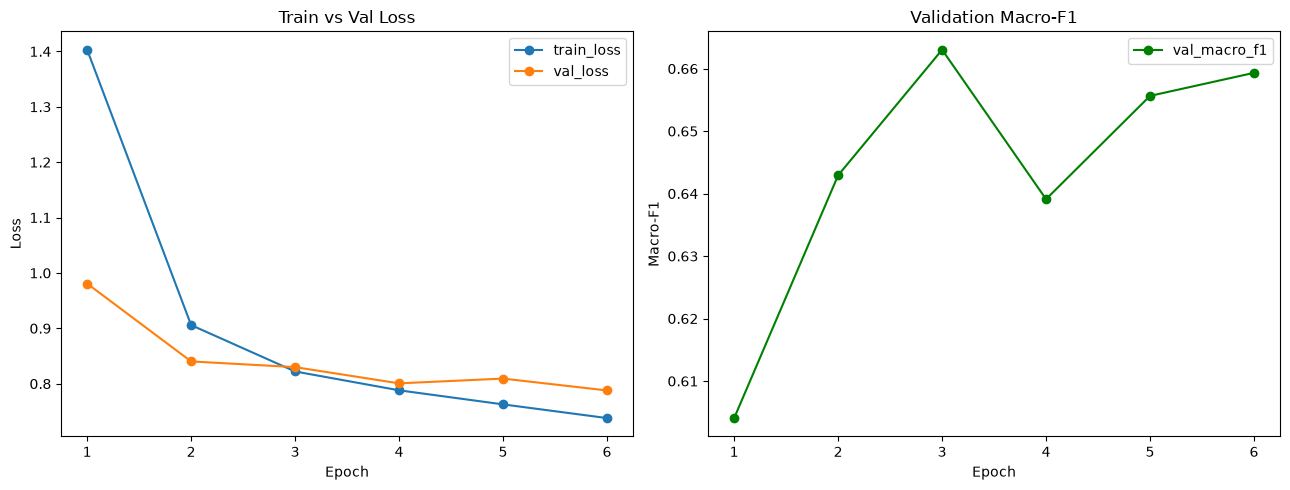

In [13]:
#Plot train/val curves (loss + macro-F1 per epoch)
log_history = trainer.state.log_history

train_loss = [(x["epoch"], x["loss"]) for x in log_history if "loss" in x and "eval_loss" not in x]
eval_loss = [(x["epoch"], x["eval_loss"]) for x in log_history if "eval_loss" in x]
eval_f1 = [(x["epoch"], x["eval_macro_f1"]) for x in log_history if "eval_macro_f1" in x]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if train_loss:
    axes[0].plot(*zip(*train_loss), label="train_loss", marker="o")
if eval_loss:
    axes[0].plot(*zip(*eval_loss), label="val_loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Val Loss")
axes[0].legend()

if eval_f1:
    axes[1].plot(*zip(*eval_f1), label="val_macro_f1", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Validation Macro-F1")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/train_curves.png", dpi=150)
plt.show()




=== VALIDATION SET ===
Accuracy: 0.6664743219849971
Macro-F1: 0.6630265375482267
Weighted-F1: 0.6524755729869772
                                 precision    recall  f1-score   support

                      Neoplasms     0.7030    0.9158    0.7954       380
      Digestive system diseases     0.5462    0.7933    0.6469       179
        Nervous system diseases     0.5830    0.6234    0.6025       231
        Cardiovascular diseases     0.7389    0.7732    0.7557       366
General pathological conditions     0.6839    0.4125    0.5146       577

                       accuracy                         0.6665      1733
                      macro avg     0.6510    0.7036    0.6630      1733
                   weighted avg     0.6720    0.6665    0.6525      1733



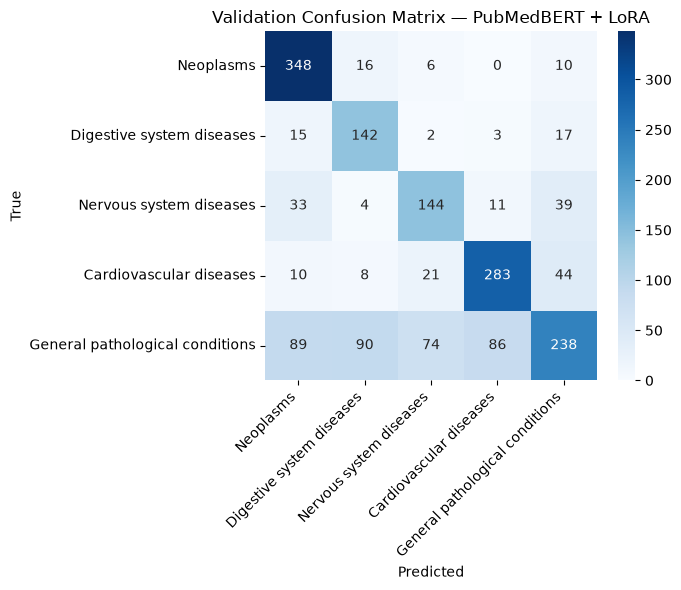

In [14]:

### CELL 12 — Final evaluation on validation set (best checkpoint already loaded)
val_preds_output = trainer.predict(val_tok)
val_preds = np.argmax(val_preds_output.predictions, axis=-1)
val_labels = val_preds_output.label_ids

class_names = [
    "Neoplasms",
    "Digestive system diseases",
    "Nervous system diseases",
    "Cardiovascular diseases",
    "General pathological conditions",
]

print("=== VALIDATION SET ===")
print("Accuracy:", accuracy_score(val_labels, val_preds))
print("Macro-F1:", f1_score(val_labels, val_preds, average="macro"))
print("Weighted-F1:", f1_score(val_labels, val_preds, average="weighted"))
print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix — PubMedBERT + LoRA")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/val_confusion_matrix.png", dpi=150)
plt.show()



=== TEST SET (FINAL) ===
Accuracy: 0.6520083102493075
Macro-F1: 0.6538552362068013
Weighted-F1: 0.6342184002126234
                                 precision    recall  f1-score   support

                      Neoplasms     0.6831    0.8957    0.7751       633
      Digestive system diseases     0.5604    0.7759    0.6508       299
        Nervous system diseases     0.5972    0.6701    0.6316       385
        Cardiovascular diseases     0.7173    0.7738    0.7445       610
General pathological conditions     0.6390    0.3684    0.4673       961

                       accuracy                         0.6520      2888
                      macro avg     0.6394    0.6968    0.6539      2888
                   weighted avg     0.6515    0.6520    0.6342      2888



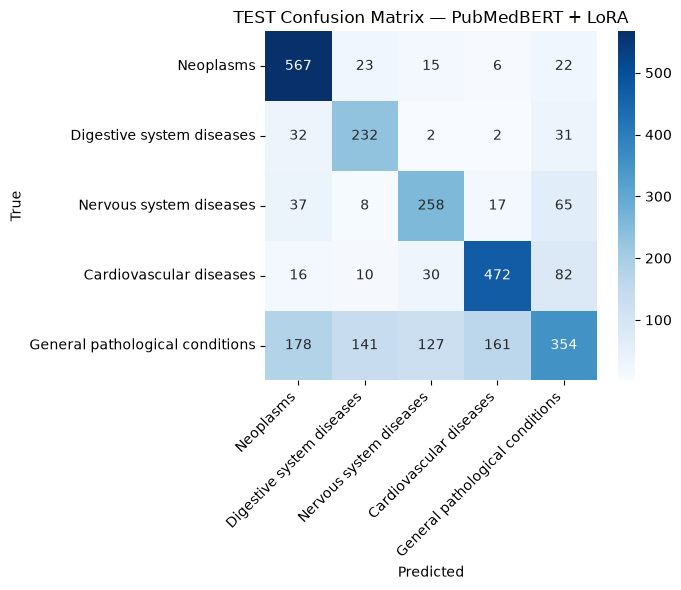

In [17]:
RUN_TEST_EVAL = True

if RUN_TEST_EVAL:
    test_preds_output = trainer.predict(test_tok)
    test_preds = np.argmax(test_preds_output.predictions, axis=-1)
    test_labels = test_preds_output.label_ids

    print("=== TEST SET (FINAL) ===")
    print("Accuracy:", accuracy_score(test_labels, test_preds))
    print("Macro-F1:", f1_score(test_labels, test_preds, average="macro"))
    print("Weighted-F1:", f1_score(test_labels, test_preds, average="weighted"))
    print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

    cm_test = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("TEST Confusion Matrix — PubMedBERT + LoRA")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/test_confusion_matrix.png", dpi=150)
    plt.show()


